# Regressão Softmax com dados do MNIST

## Objetivo

O objetivo deste notebook é ilustrar o uso de praticamente a mesma rede desenvolvida para a classificação das flores Íris, porém agora com o problema de classificação de dígitos manuscritos utilizando o dataset MNIST.
As principais diferenças são:
- tipo do dado, agora imagem com muito atributos: 28 x 28 pixels
- número de amostras, muito maior, 60 mil
Neste exercício será possível a interpretação do significado dos parâmetros treinados

## Importação das bibliotecas

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable

import torchvision

## Carregamento dos dados do MNIST

In [3]:
! git clone https://github.com/vcasadei/MNIST.git

Cloning into 'MNIST'...
remote: Enumerating objects: 10, done.
remote: Total 10 (delta 0), reused 0 (delta 0), pack-reused 10 (from 1)
Receiving objects: 100% (10/10), 11.01 MiB | 8.91 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
!ls MNIST

processed  raw


In [5]:
dataset_dir = 'MNIST/'

x_train, y_train = torch.load(dataset_dir + 'processed/training.pt')

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 60000

Dimensões dos dados das imagens:    torch.Size([60000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0, dtype=torch.uint8) tensor(255, dtype=torch.uint8)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento, normalização e seleção dos dados do MNIST

Neste exemplo utilizaremos apenas 1000 amostras de treinamento.

In [6]:
x_train = x_train.float()

x_train = x_train / 255.

if True:
    n_samples_train = 1000

    x_train = x_train[:n_samples_train]
    y_train = y_train[:n_samples_train]

print("Amostras de treinamento:", x_train.size(0))

print("\nDimensões dos dados das imagens:   ", x_train.size())
print("Valores mínimo e máximo dos pixels:", torch.min(x_train), torch.max(x_train))
print("Tipo dos dados das imagens:        ", type(x_train))
print("Tipo das classes das imagens:      ", type(y_train))

Amostras de treinamento: 1000

Dimensões dos dados das imagens:    torch.Size([1000, 28, 28])
Valores mínimo e máximo dos pixels: tensor(0.) tensor(1.)
Tipo dos dados das imagens:         <class 'torch.Tensor'>
Tipo das classes das imagens:       <class 'torch.Tensor'>


### Carregamento e normalização dos dados de validação

In [7]:
x_val, y_val = torch.load(dataset_dir + 'processed/test.pt')

x_val = x_val.float()
x_val = x_val / 255.

# Limit validation samples for consistency with training set, if needed
# If you want to use the full test set for validation, comment this block
if True:
    n_samples_val = 200 # Using a smaller validation set for demonstration

    x_val = x_val[:n_samples_val]
    y_val = y_val[:n_samples_val]

print("Amostras de validação:", x_val.size(0))

print("\nDimensões dos dados das imagens de validação:   ", x_val.size())
print("Valores mínimo e máximo dos pixels de validação:", torch.min(x_val), torch.max(x_val))
print("Tipo dos dados das imagens de validação:        ", type(x_val))
print("Tipo das classes das imagens de validação:      ", type(y_val))

Amostras de validação: 200

Dimensões dos dados das imagens de validação:    torch.Size([200, 28, 28])
Valores mínimo e máximo dos pixels de validação: tensor(0.) tensor(1.)
Tipo dos dados das imagens de validação:         <class 'torch.Tensor'>
Tipo das classes das imagens de validação:       <class 'torch.Tensor'>


### Visualizando os dados

(np.float64(-0.5), np.float64(232.5), np.float64(87.5), np.float64(-0.5))

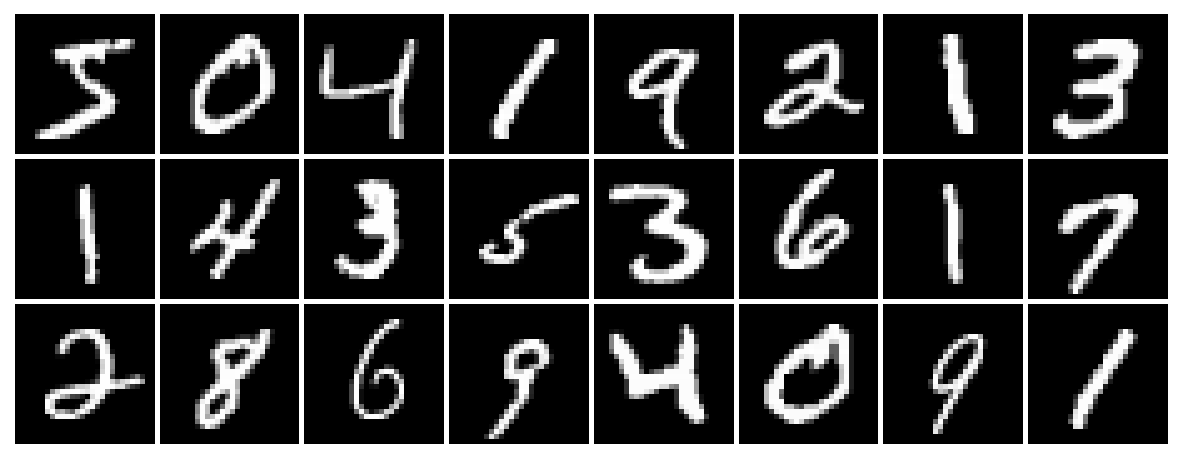

In [8]:
n_samples = 24

# cria um grid com as imagens
grid = torchvision.utils.make_grid(x_train[:n_samples].unsqueeze(dim=1), pad_value=1.0, padding=1)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off')

### Visualizando uma imagem com o matplotlib

class: tensor(5)


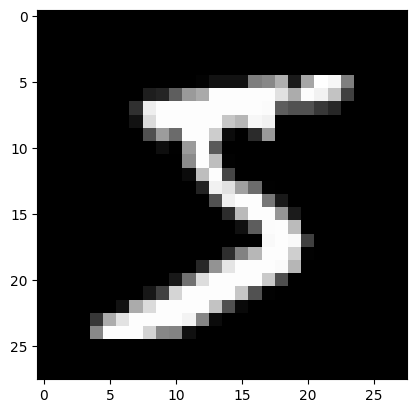

In [9]:
image  = x_train[0]
target = y_train[0]

plt.imshow(image.numpy(), cmap='gray')
print('class:', target)

## Modelo

In [10]:
model = torch.nn.Linear(28*28, 10) # 28*28 atributos de entrada e 10 neurônios na sáida

### Testando um predict com poucas amostras

In [11]:
xin = x_train[:5].view(-1,28*28)
score = model(Variable(xin))
score

tensor([[-0.1558, -0.2736, -0.0393,  0.0390, -0.0687, -0.3568, -0.2728,  0.1167,
          0.1113, -0.0771],
        [-0.3244, -0.0738, -0.2270,  0.0823,  0.1458,  0.1150,  0.1869,  0.1735,
          0.0100,  0.1537],
        [-0.0102, -0.1693,  0.0943, -0.0842, -0.0269, -0.1288,  0.2441, -0.0268,
         -0.2675, -0.0052],
        [-0.2214, -0.1632,  0.1881, -0.1915,  0.1212, -0.0197,  0.2430,  0.1114,
         -0.0353, -0.0577],
        [-0.2808,  0.0938,  0.1191, -0.3372,  0.0906, -0.0074,  0.1255,  0.0173,
          0.1299, -0.0307]], grad_fn=<AddmmBackward0>)

## Treinamento

### Inicialização dos parâmetros

In [12]:
epochs = 100
learningRate = 0.5

# Utilizaremos CrossEntropyLoss como função de perda
criterion = torch.nn.CrossEntropyLoss()

# Gradiente descendente
optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)

### Laço de treinamento dos pesos

Epoch[1/100], loss: 2.326432, acc: 0.098000


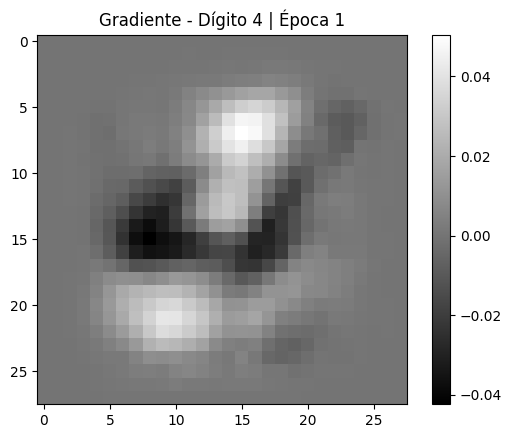

Epoch[2/100], loss: 1.813249, acc: 0.600000


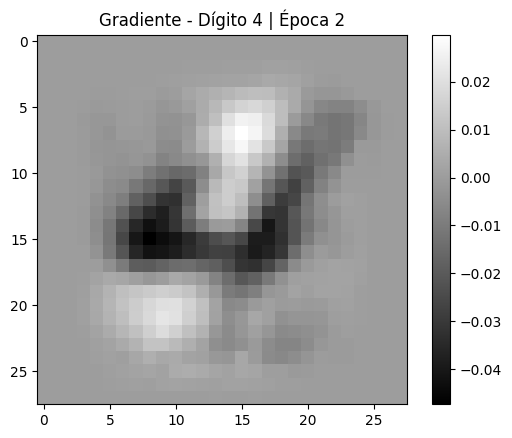

Epoch[3/100], loss: 1.476917, acc: 0.752000


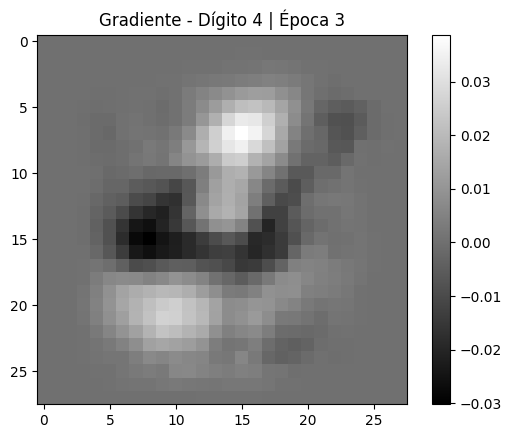

Epoch[4/100], loss: 1.249558, acc: 0.774000


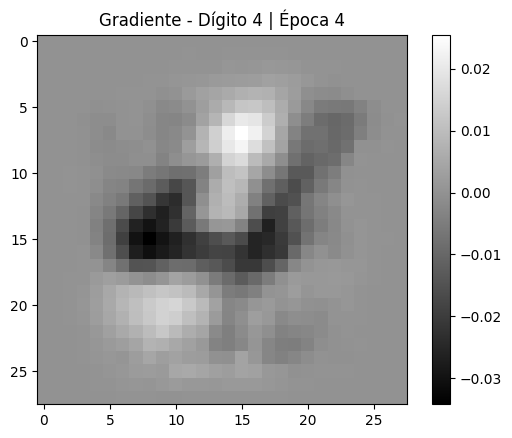

Epoch[5/100], loss: 1.098275, acc: 0.807000


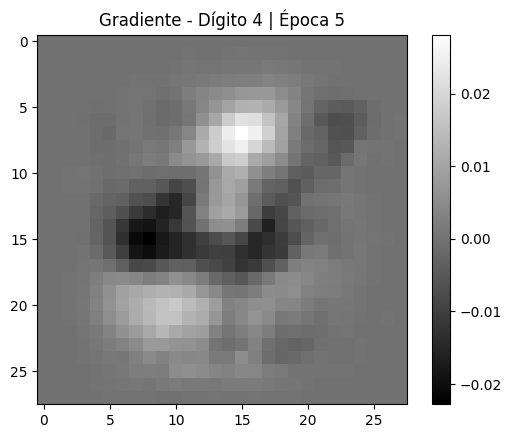

Epoch[6/100], loss: 0.985918, acc: 0.820000


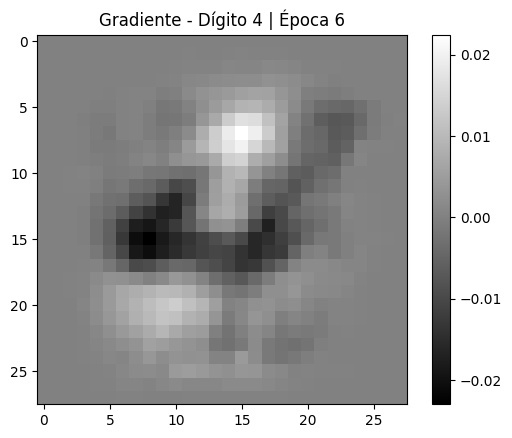

Epoch[7/100], loss: 0.904474, acc: 0.826000


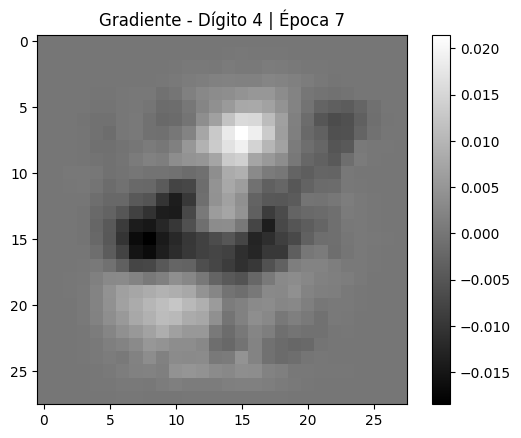

Epoch[8/100], loss: 0.841921, acc: 0.835000


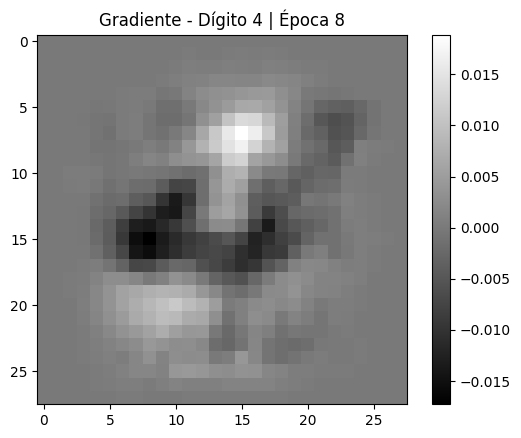

Epoch[9/100], loss: 0.792140, acc: 0.842000


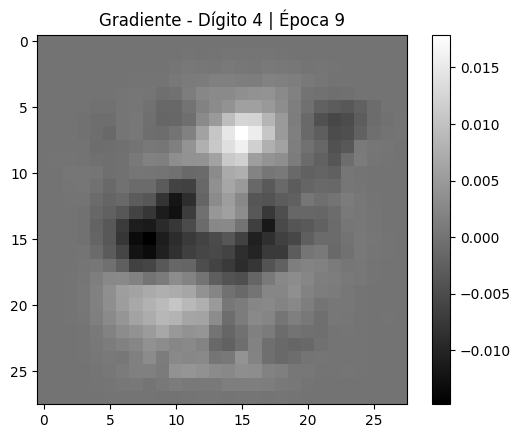

Epoch[10/100], loss: 0.751203, acc: 0.848000


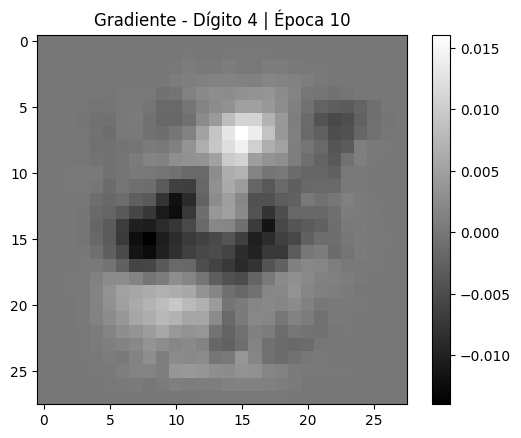

Epoch[11/100], loss: 0.716744, acc: 0.854000


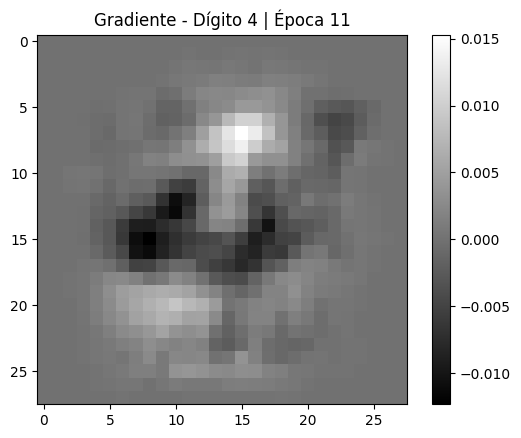

Epoch[12/100], loss: 0.687214, acc: 0.856000


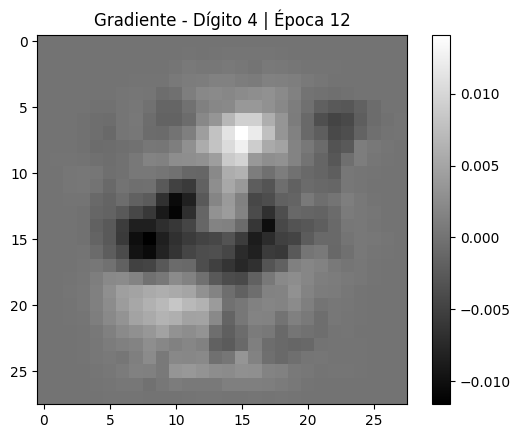

Epoch[13/100], loss: 0.661537, acc: 0.864000


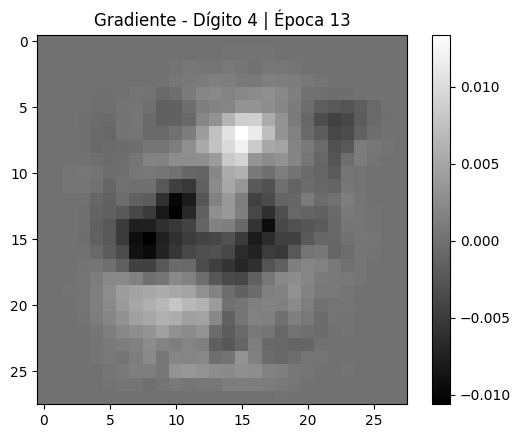

Epoch[14/100], loss: 0.638939, acc: 0.866000


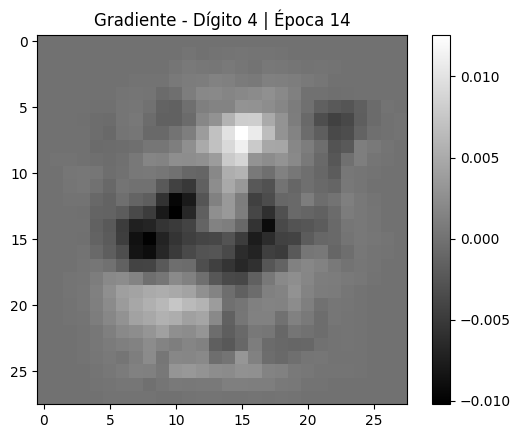

Epoch[15/100], loss: 0.618842, acc: 0.868000


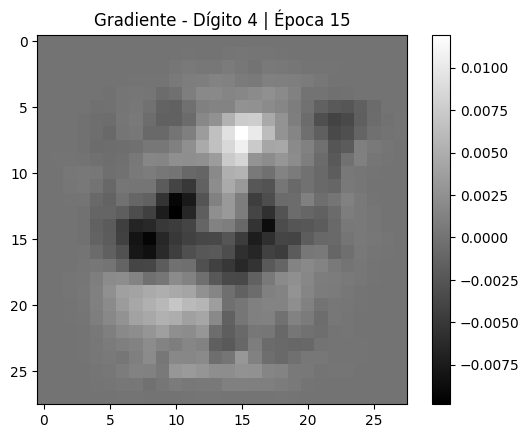

Epoch[16/100], loss: 0.600812, acc: 0.873000


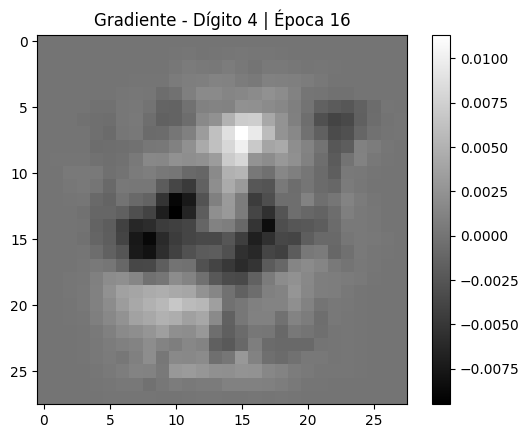

Epoch[17/100], loss: 0.584509, acc: 0.874000


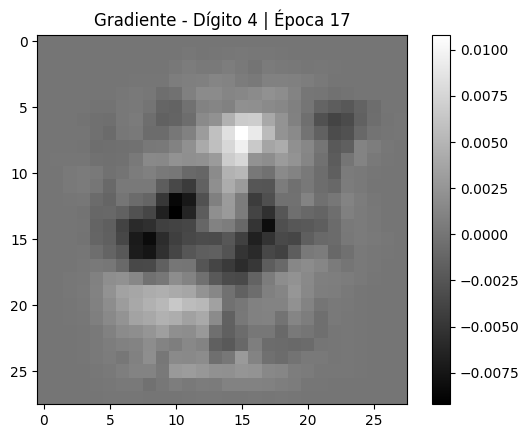

Epoch[18/100], loss: 0.569669, acc: 0.876000


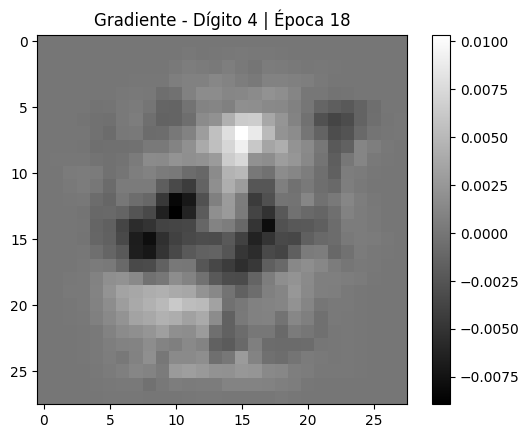

Epoch[19/100], loss: 0.556079, acc: 0.878000


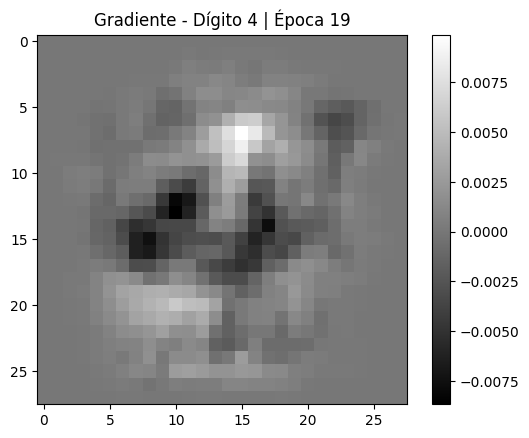

Epoch[20/100], loss: 0.543566, acc: 0.880000


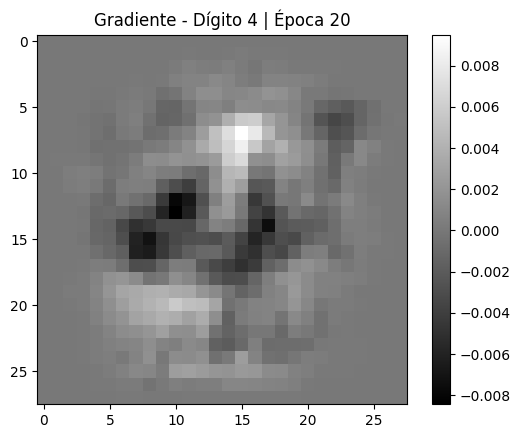

Epoch[21/100], loss: 0.531992, acc: 0.882000


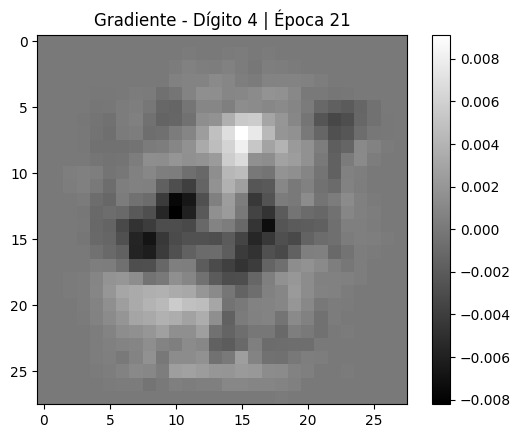

Epoch[22/100], loss: 0.521240, acc: 0.884000


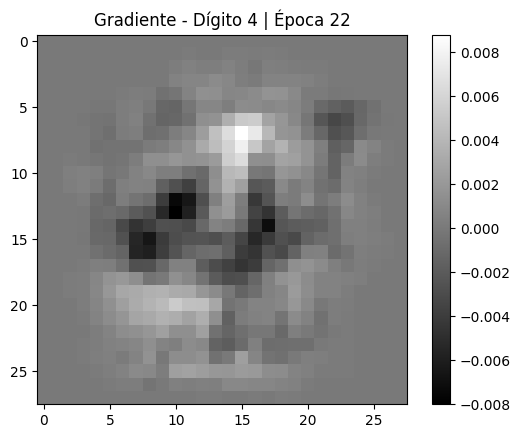

Epoch[23/100], loss: 0.511212, acc: 0.888000


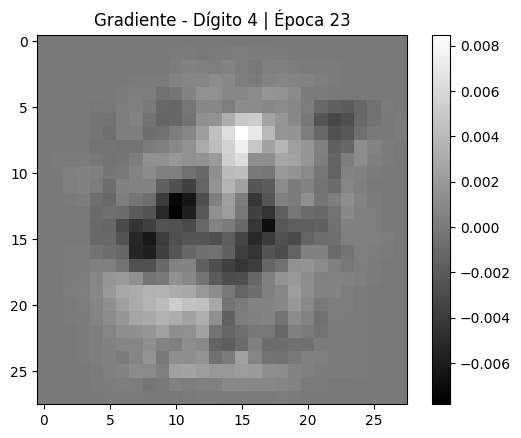

Epoch[24/100], loss: 0.501827, acc: 0.890000


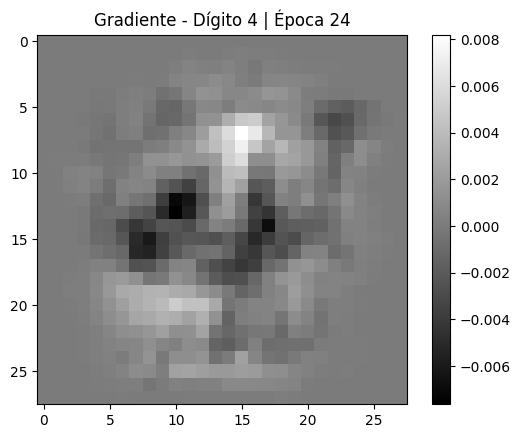

Epoch[25/100], loss: 0.493016, acc: 0.889000


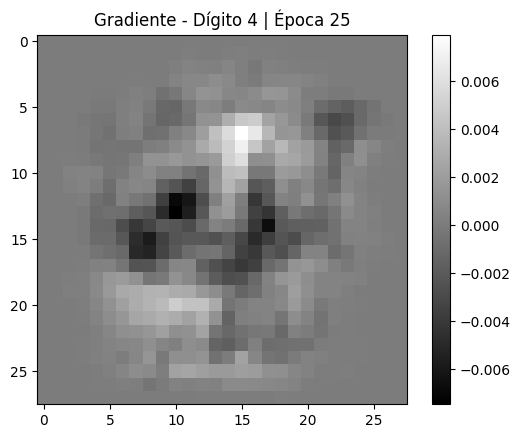

Epoch[26/100], loss: 0.484719, acc: 0.889000


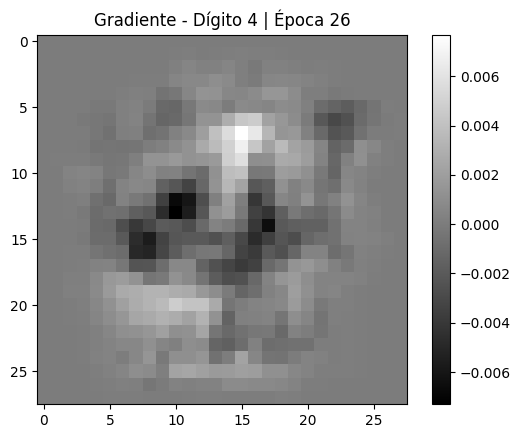

Epoch[27/100], loss: 0.476886, acc: 0.891000


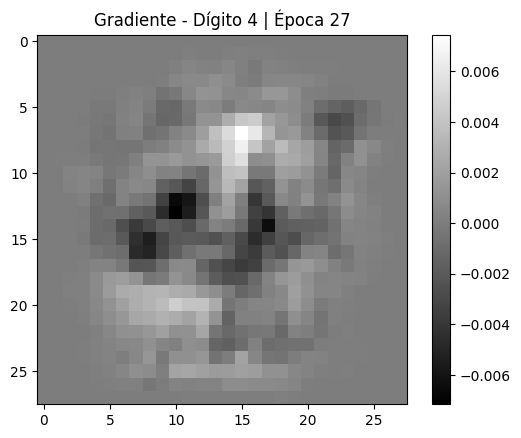

Epoch[28/100], loss: 0.469472, acc: 0.895000


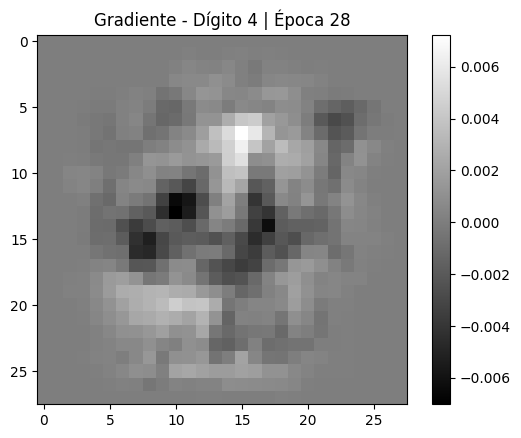

Epoch[29/100], loss: 0.462439, acc: 0.895000


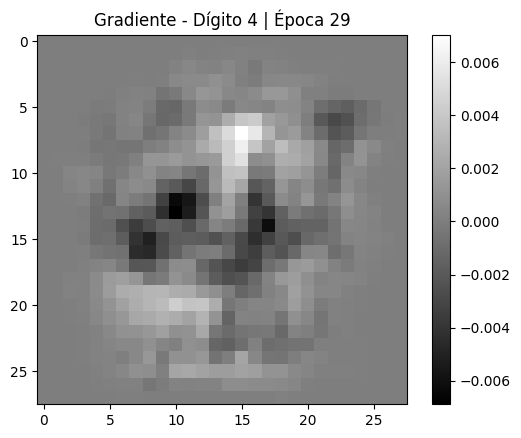

Epoch[30/100], loss: 0.455752, acc: 0.896000


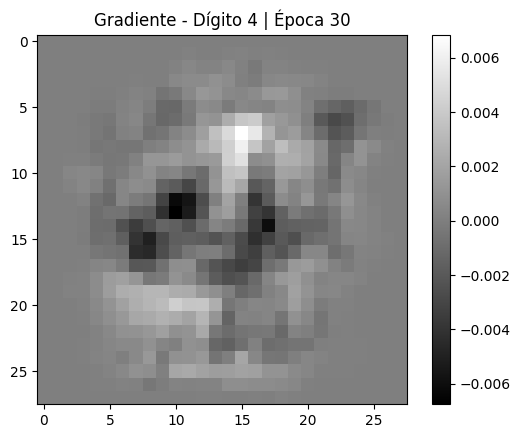

Epoch[31/100], loss: 0.449383, acc: 0.897000


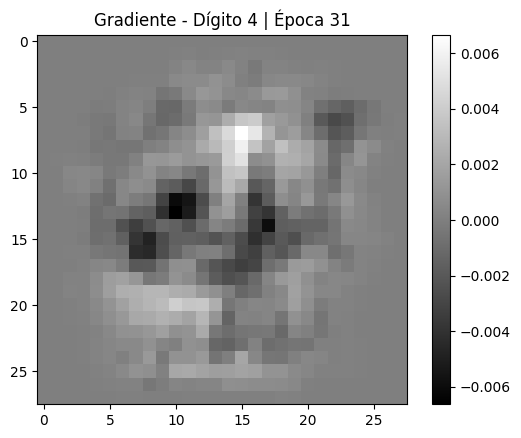

Epoch[32/100], loss: 0.443305, acc: 0.897000


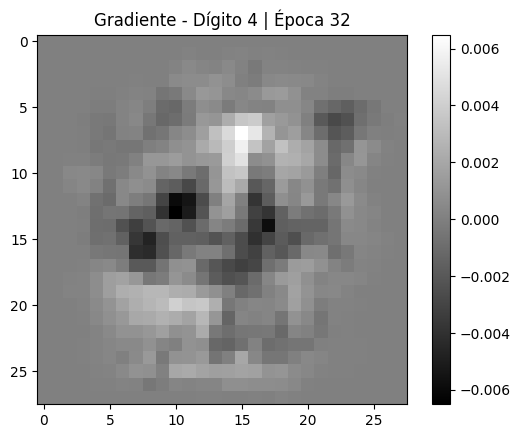

Epoch[33/100], loss: 0.437495, acc: 0.899000


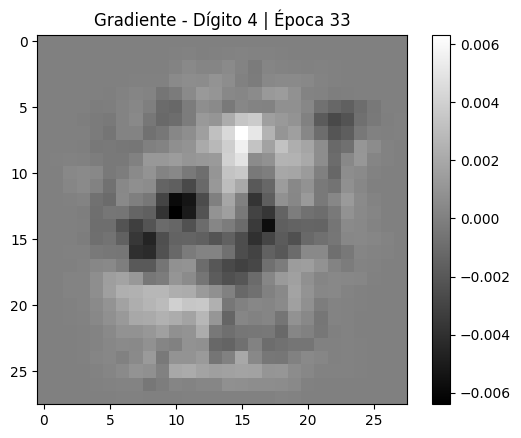

Epoch[34/100], loss: 0.431932, acc: 0.902000


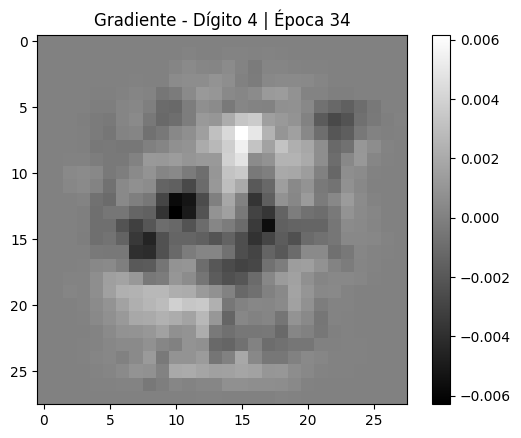

Epoch[35/100], loss: 0.426598, acc: 0.903000


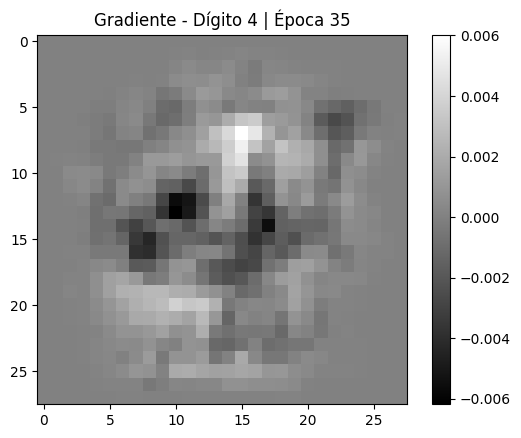

Epoch[36/100], loss: 0.421476, acc: 0.904000


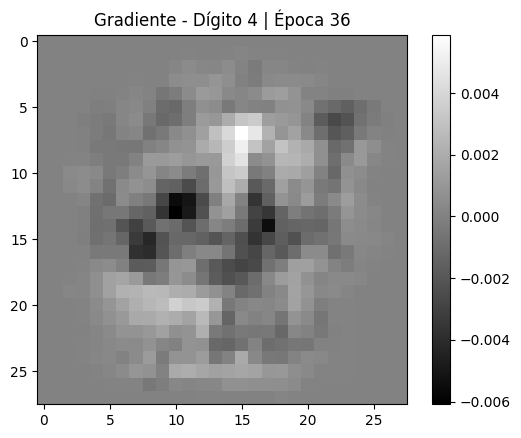

Epoch[37/100], loss: 0.416551, acc: 0.906000


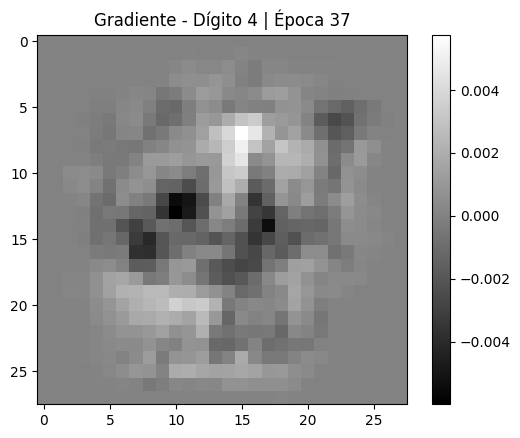

Epoch[38/100], loss: 0.411810, acc: 0.907000


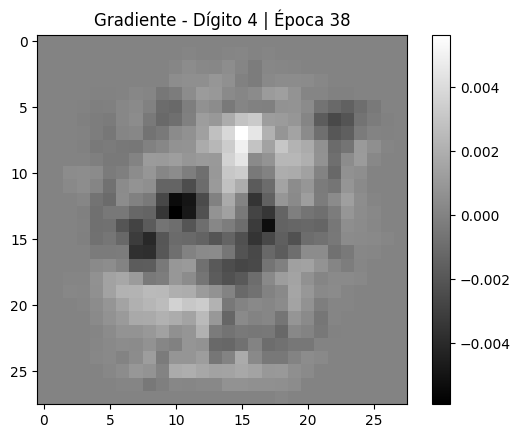

Epoch[39/100], loss: 0.407240, acc: 0.907000


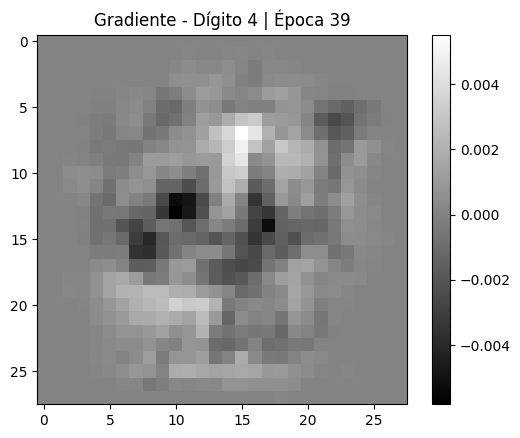

Epoch[40/100], loss: 0.402831, acc: 0.910000


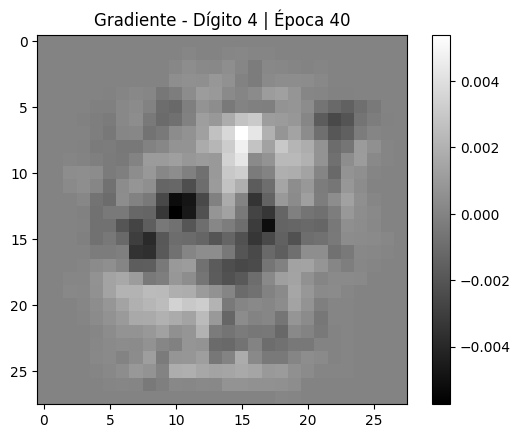

Epoch[41/100], loss: 0.398572, acc: 0.911000


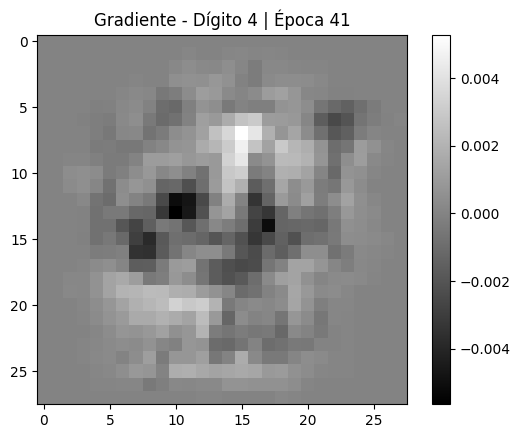

Epoch[42/100], loss: 0.394454, acc: 0.913000


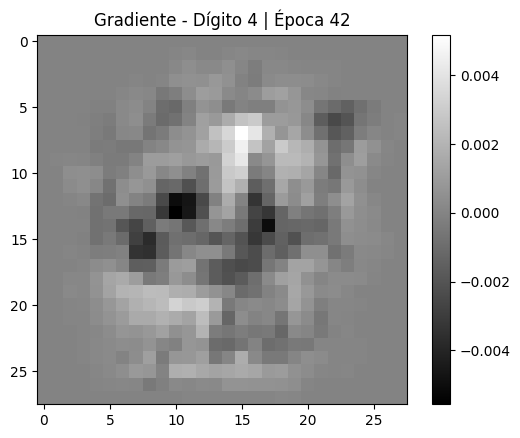

Epoch[43/100], loss: 0.390468, acc: 0.913000


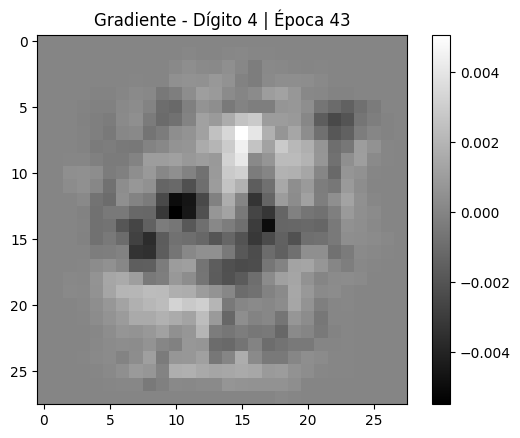

Epoch[44/100], loss: 0.386608, acc: 0.913000


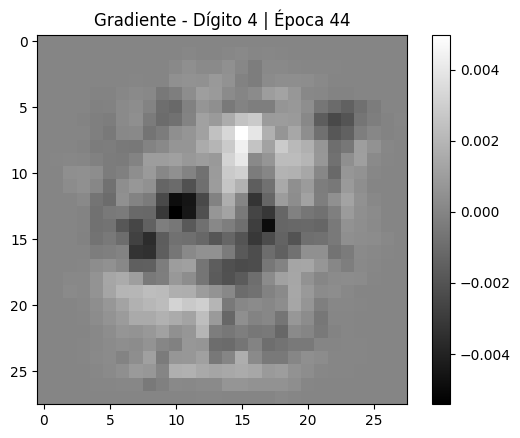

Epoch[45/100], loss: 0.382865, acc: 0.913000


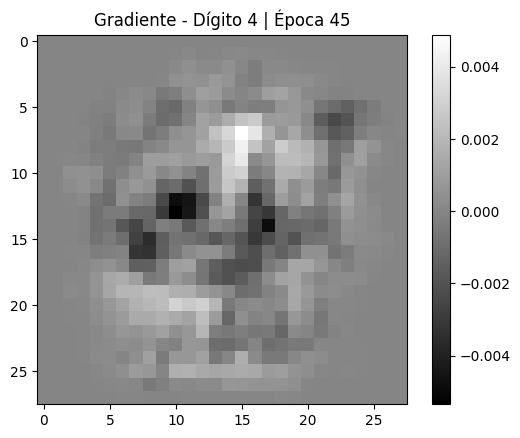

Epoch[46/100], loss: 0.379233, acc: 0.915000


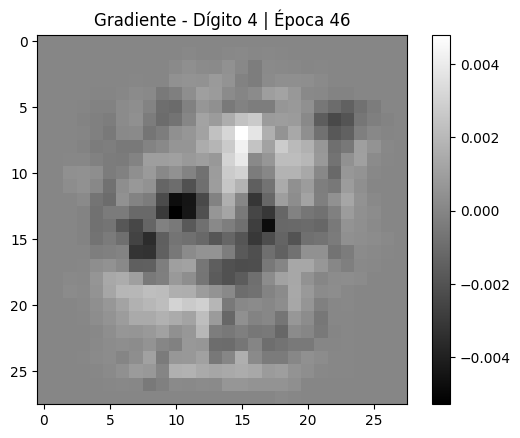

Epoch[47/100], loss: 0.375707, acc: 0.915000


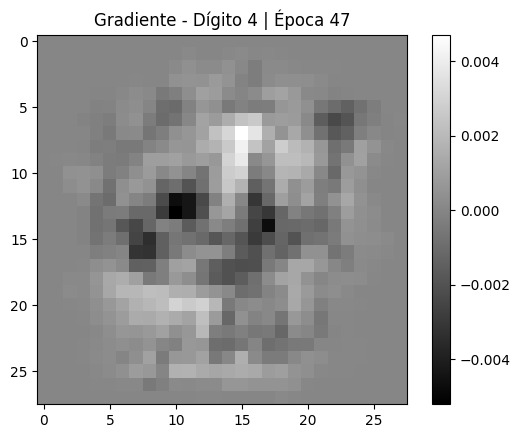

Epoch[48/100], loss: 0.372280, acc: 0.916000


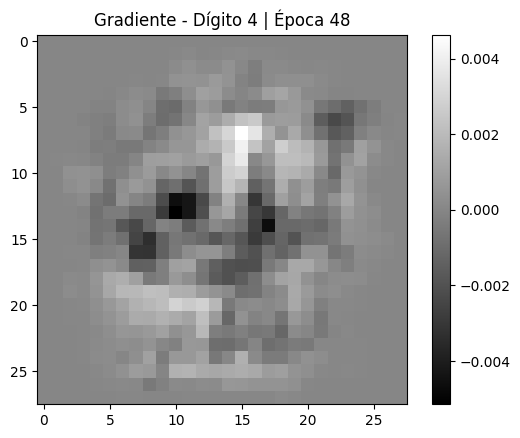

Epoch[49/100], loss: 0.368947, acc: 0.917000


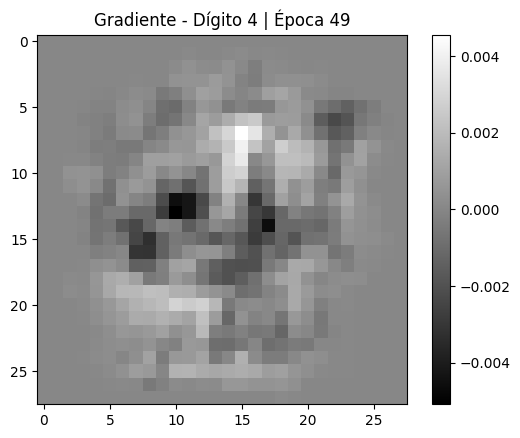

Epoch[50/100], loss: 0.365705, acc: 0.918000


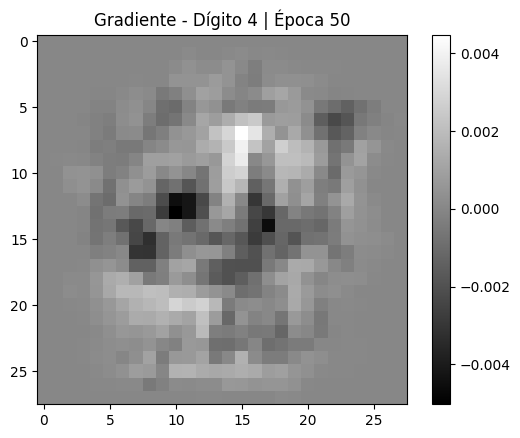

Epoch[51/100], loss: 0.362547, acc: 0.919000


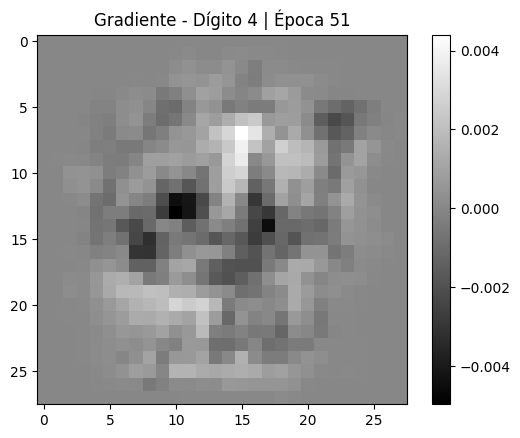

Epoch[52/100], loss: 0.359471, acc: 0.919000


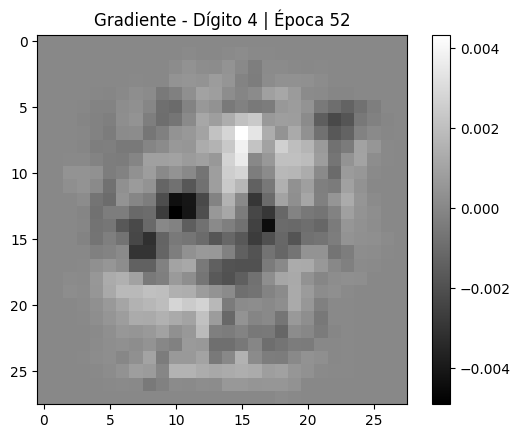

Epoch[53/100], loss: 0.356472, acc: 0.922000


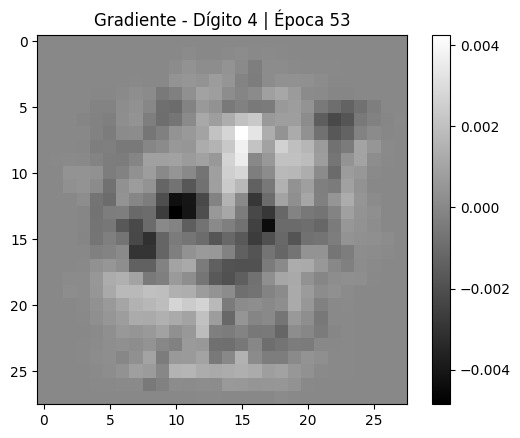

Epoch[54/100], loss: 0.353546, acc: 0.923000


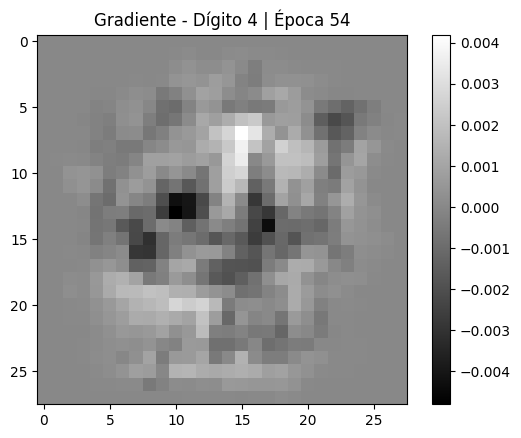

Epoch[55/100], loss: 0.350691, acc: 0.922000


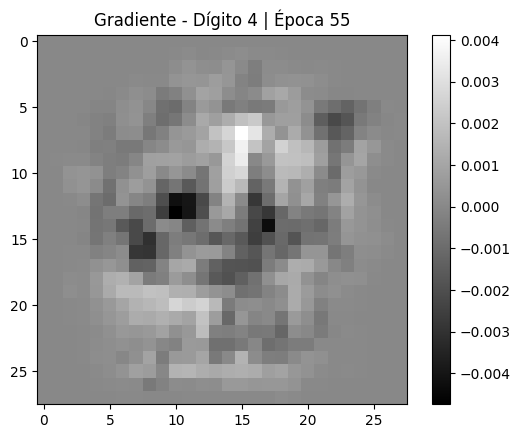

Epoch[56/100], loss: 0.347903, acc: 0.923000


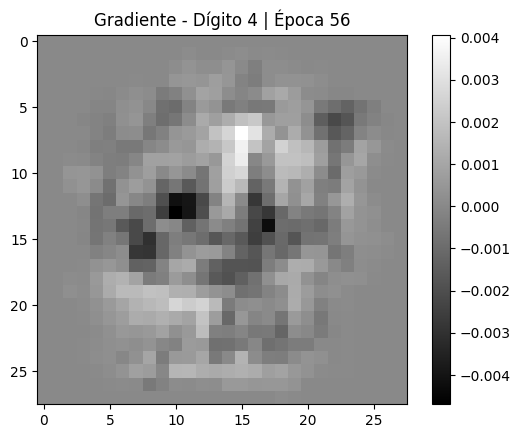

Epoch[57/100], loss: 0.345179, acc: 0.925000


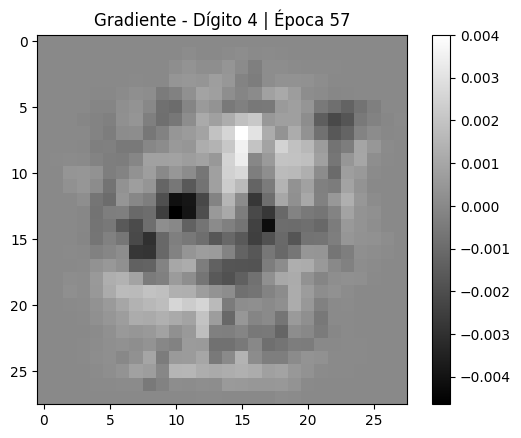

Epoch[58/100], loss: 0.342517, acc: 0.926000


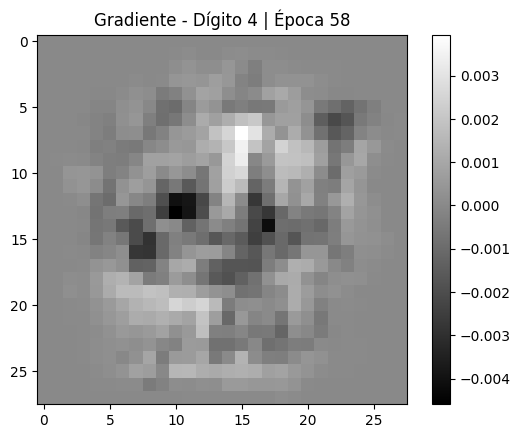

Epoch[59/100], loss: 0.339914, acc: 0.926000


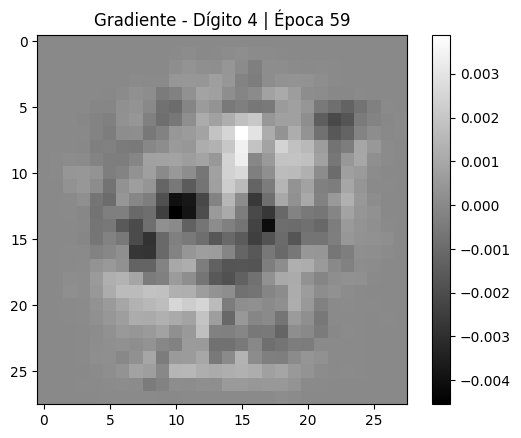

Epoch[60/100], loss: 0.337366, acc: 0.926000


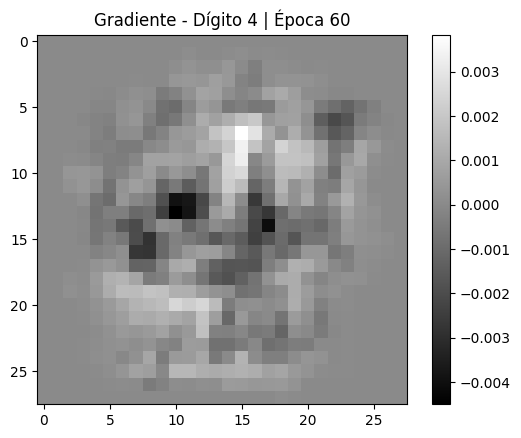

Epoch[61/100], loss: 0.334874, acc: 0.926000


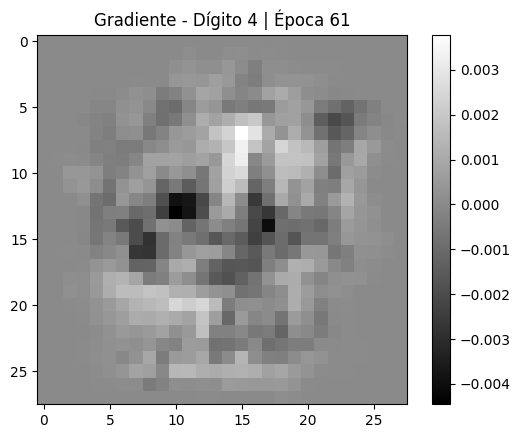

Epoch[62/100], loss: 0.332433, acc: 0.926000


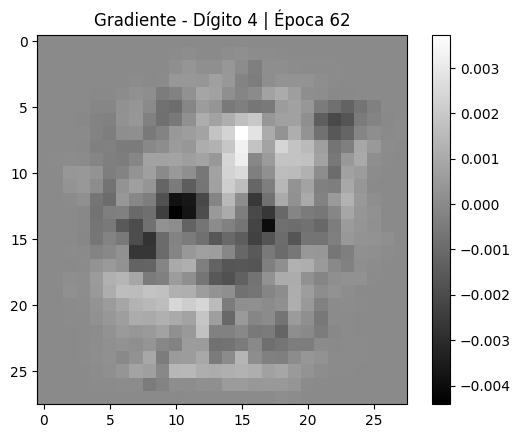

Epoch[63/100], loss: 0.330042, acc: 0.926000


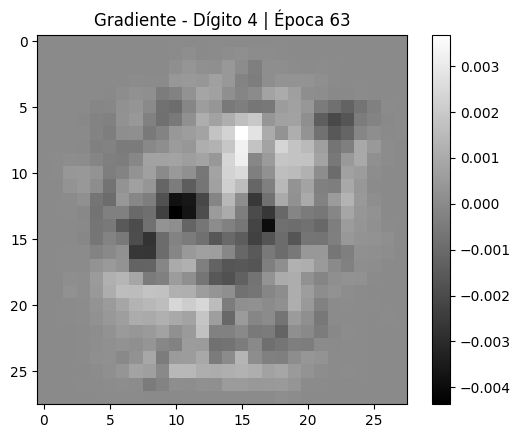

Epoch[64/100], loss: 0.327699, acc: 0.926000


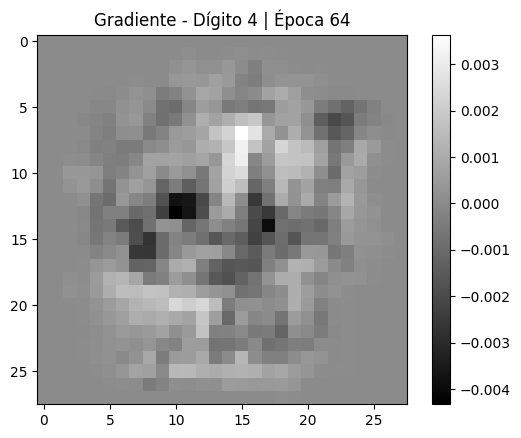

Epoch[65/100], loss: 0.325402, acc: 0.926000


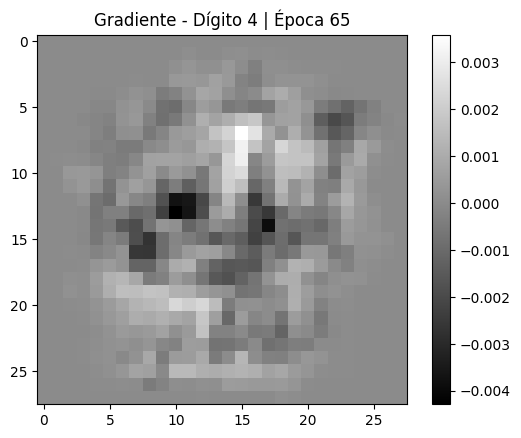

Epoch[66/100], loss: 0.323150, acc: 0.926000


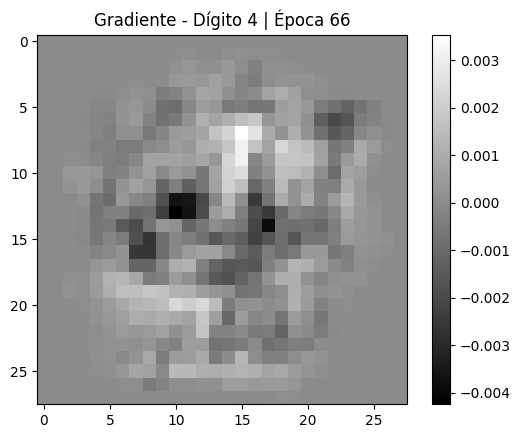

Epoch[67/100], loss: 0.320941, acc: 0.928000


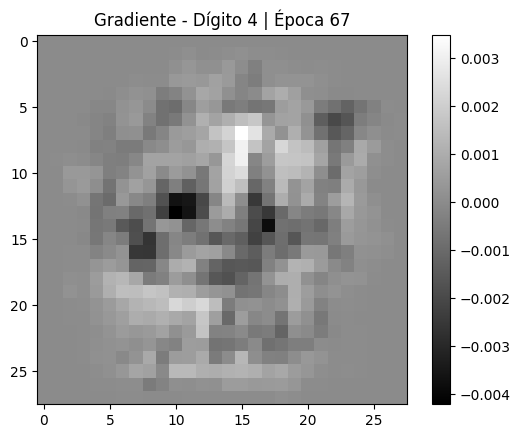

Epoch[68/100], loss: 0.318773, acc: 0.928000


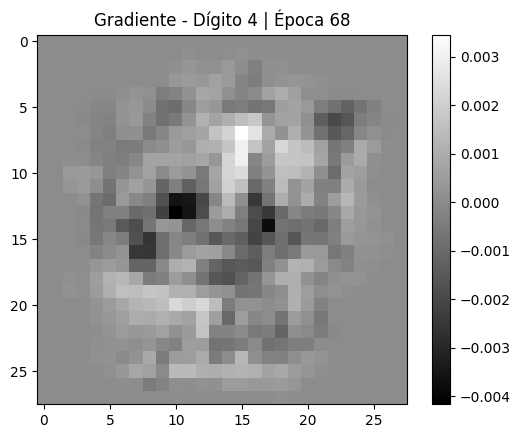

Epoch[69/100], loss: 0.316645, acc: 0.928000


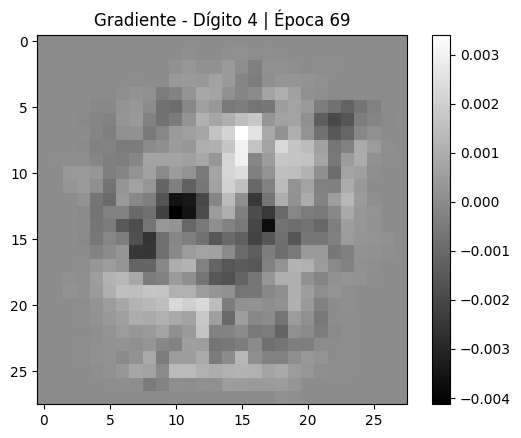

Epoch[70/100], loss: 0.314556, acc: 0.929000


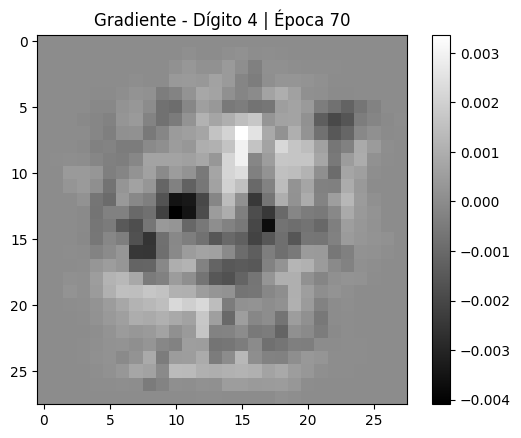

Epoch[71/100], loss: 0.312504, acc: 0.930000


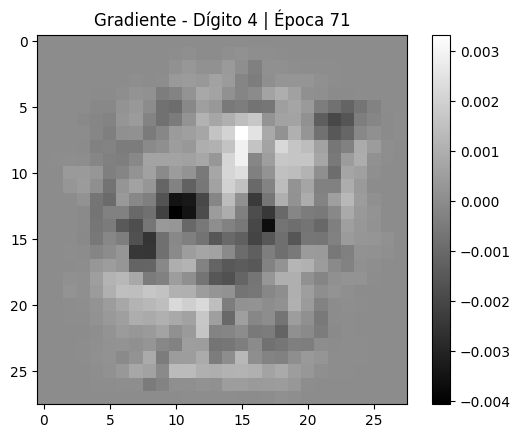

Epoch[72/100], loss: 0.310487, acc: 0.930000


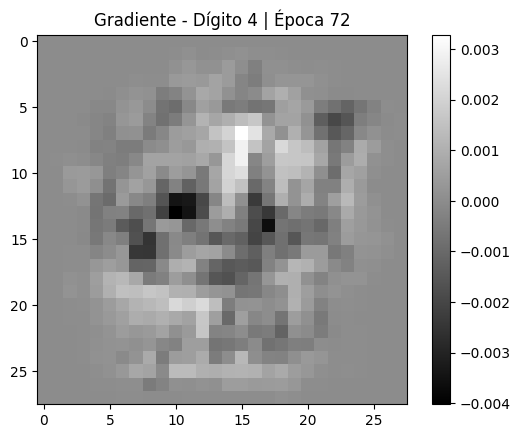

Epoch[73/100], loss: 0.308506, acc: 0.930000


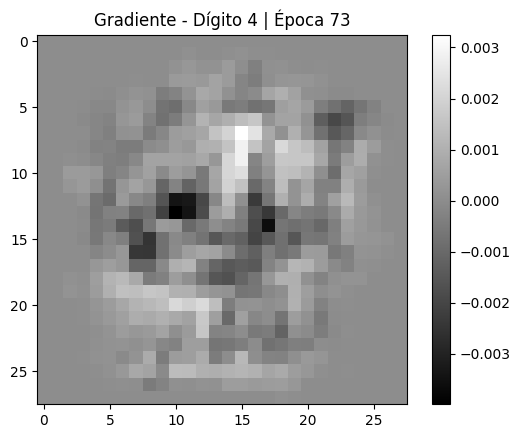

Epoch[74/100], loss: 0.306558, acc: 0.930000


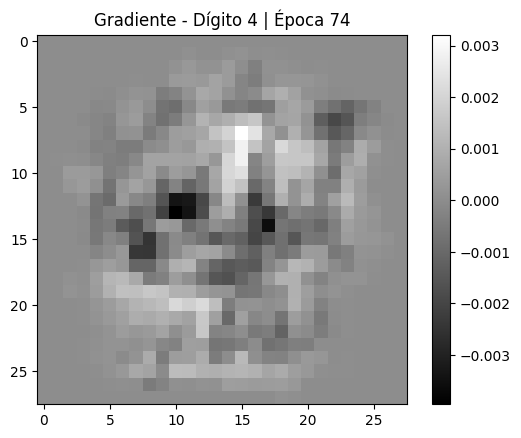

Epoch[75/100], loss: 0.304643, acc: 0.930000


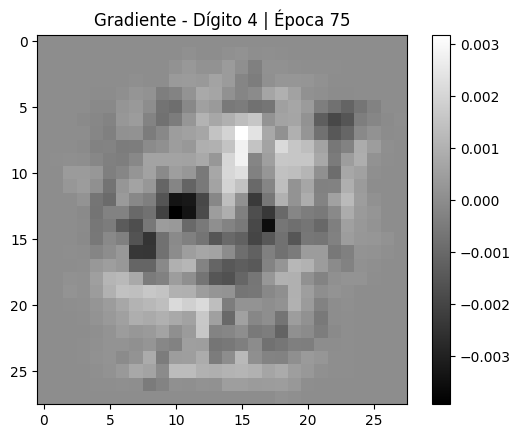

Epoch[76/100], loss: 0.302759, acc: 0.932000


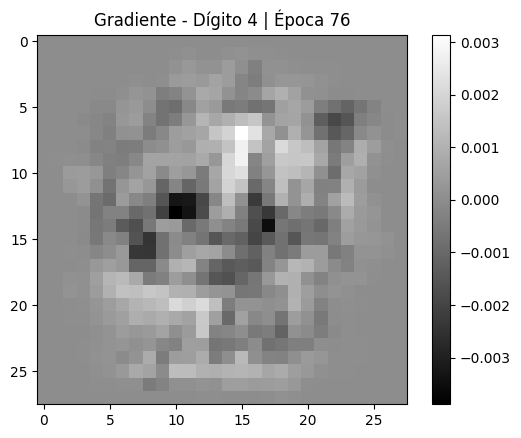

Epoch[77/100], loss: 0.300905, acc: 0.934000


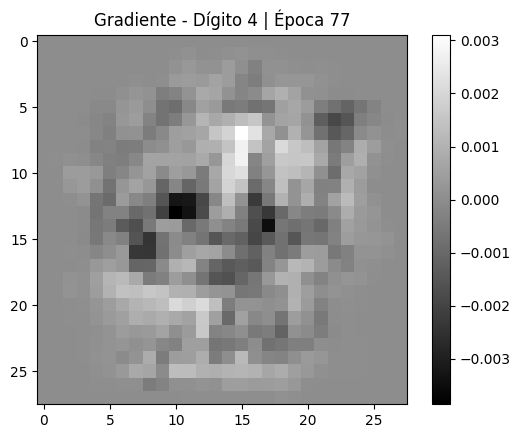

Epoch[78/100], loss: 0.299082, acc: 0.934000


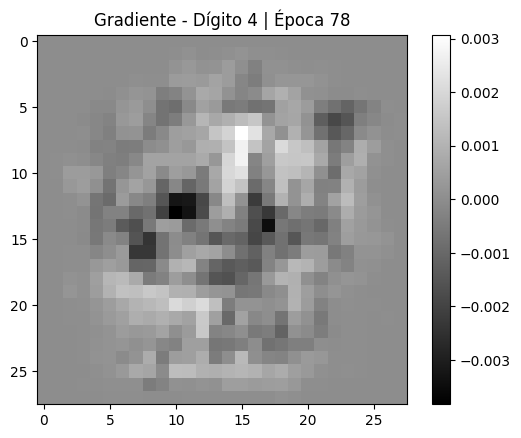

Epoch[79/100], loss: 0.297287, acc: 0.934000


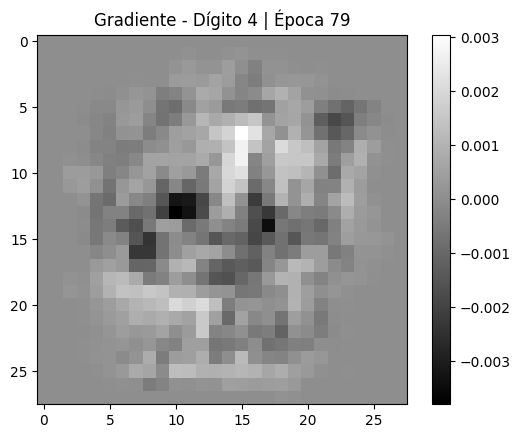

Epoch[80/100], loss: 0.295520, acc: 0.934000


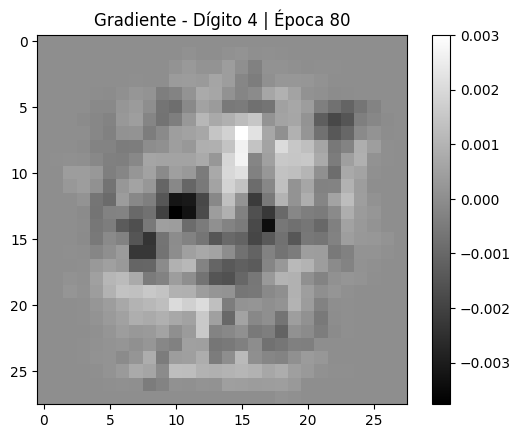

Epoch[81/100], loss: 0.293780, acc: 0.935000


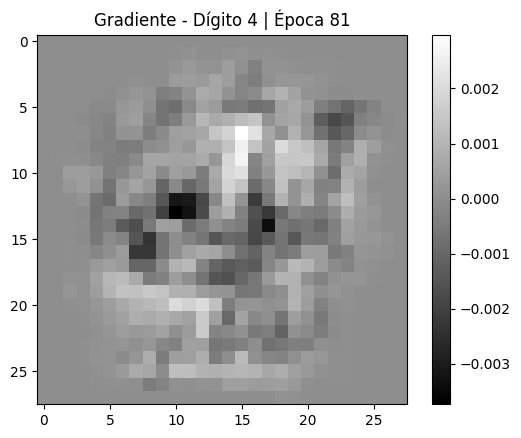

Epoch[82/100], loss: 0.292066, acc: 0.935000


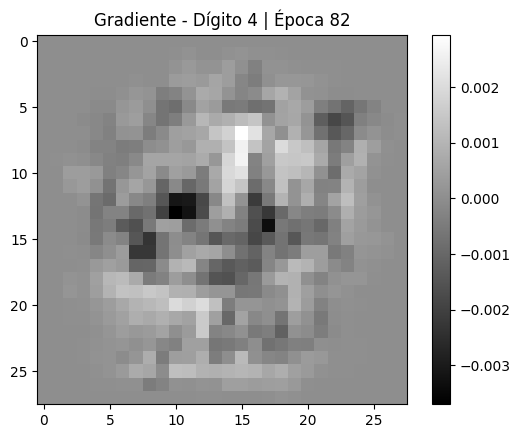

Epoch[83/100], loss: 0.290378, acc: 0.935000


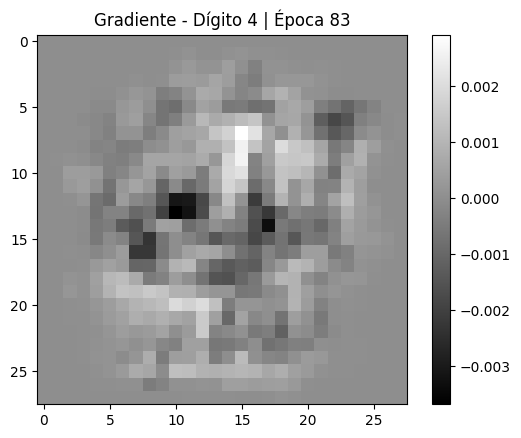

Epoch[84/100], loss: 0.288715, acc: 0.935000


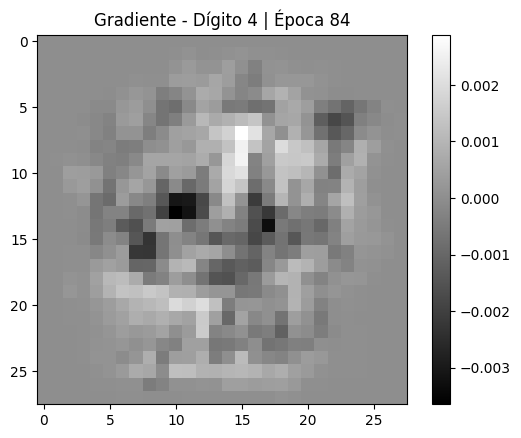

Epoch[85/100], loss: 0.287075, acc: 0.936000


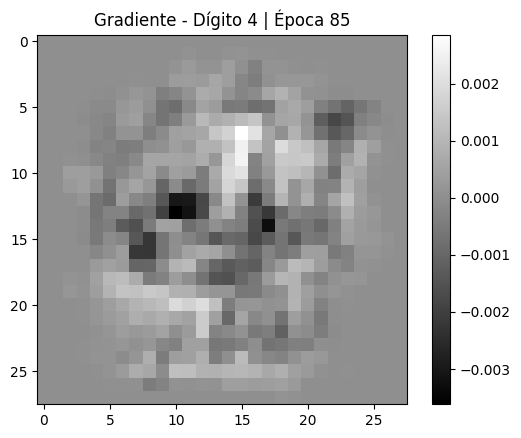

Epoch[86/100], loss: 0.285459, acc: 0.936000


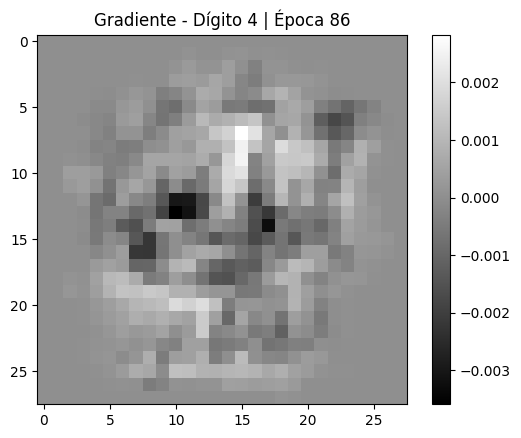

Epoch[87/100], loss: 0.283866, acc: 0.937000


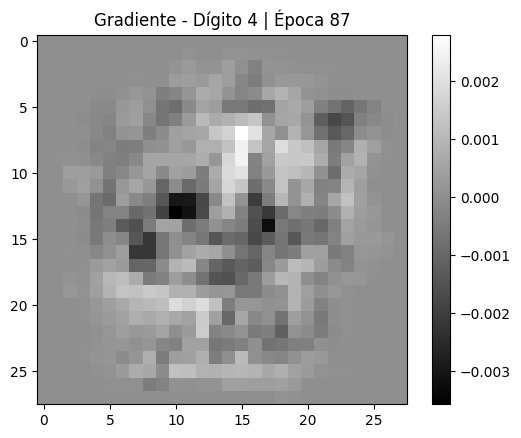

Epoch[88/100], loss: 0.282296, acc: 0.937000


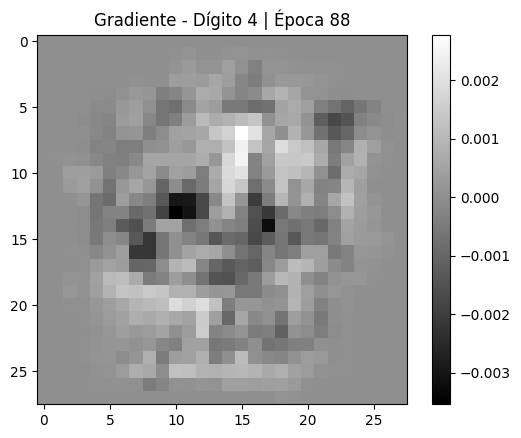

Epoch[89/100], loss: 0.280747, acc: 0.937000


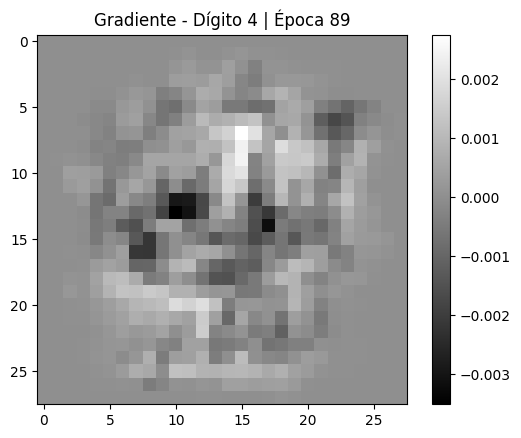

Epoch[90/100], loss: 0.279218, acc: 0.937000


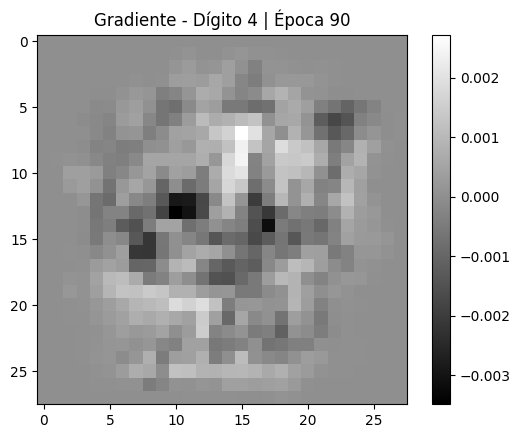

Epoch[91/100], loss: 0.277711, acc: 0.937000


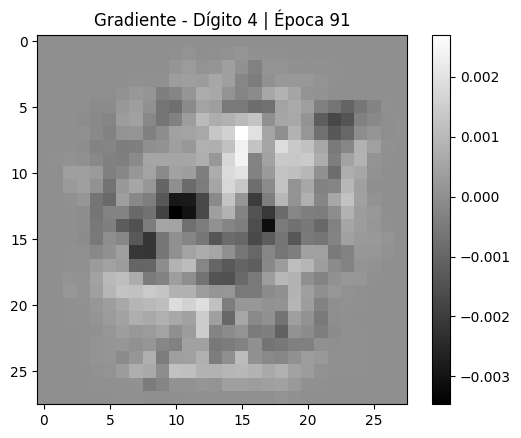

Epoch[92/100], loss: 0.276223, acc: 0.938000


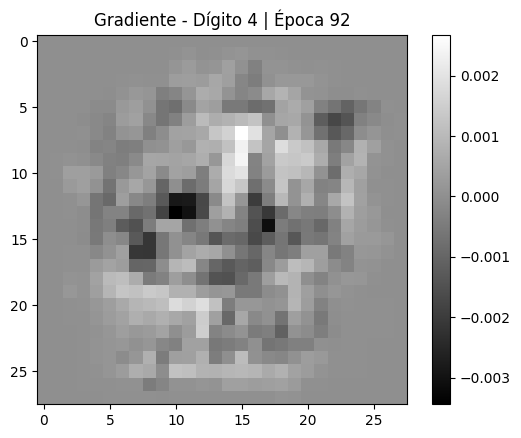

Epoch[93/100], loss: 0.274755, acc: 0.938000


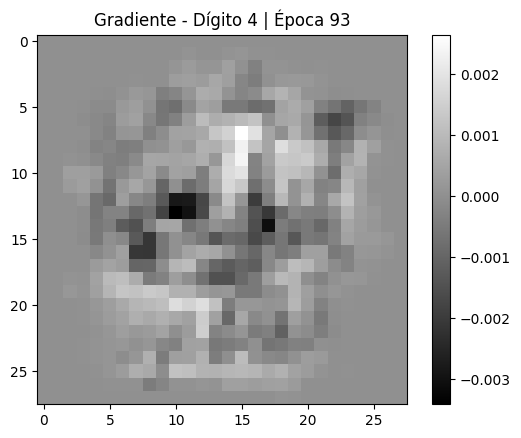

Epoch[94/100], loss: 0.273307, acc: 0.941000


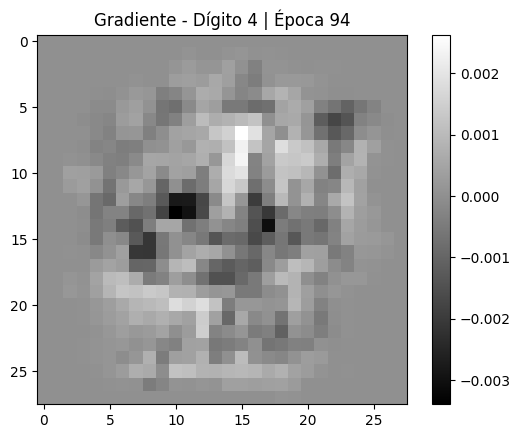

Epoch[95/100], loss: 0.271876, acc: 0.942000


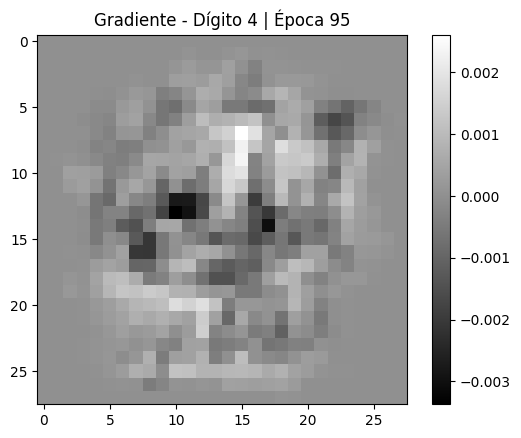

Epoch[96/100], loss: 0.270464, acc: 0.943000


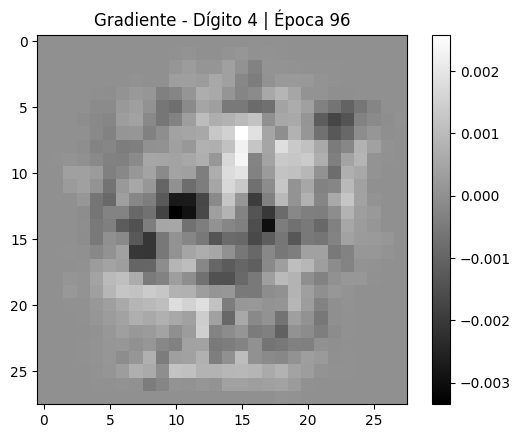

Epoch[97/100], loss: 0.269069, acc: 0.943000


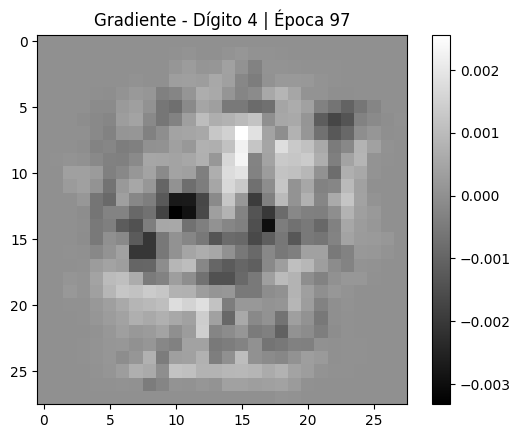

Epoch[98/100], loss: 0.267692, acc: 0.944000


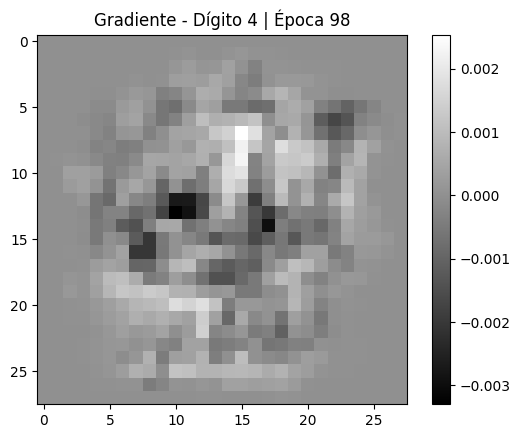

Epoch[99/100], loss: 0.266332, acc: 0.944000


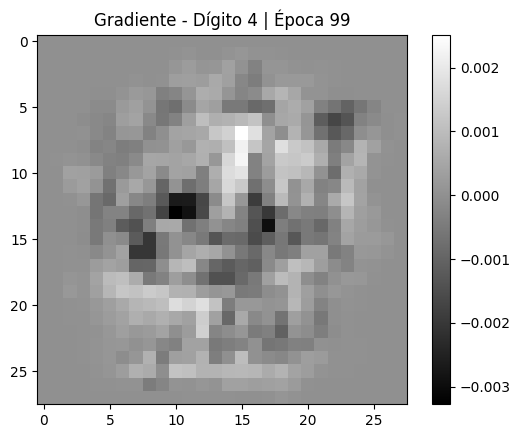

Epoch[100/100], loss: 0.264988, acc: 0.945000


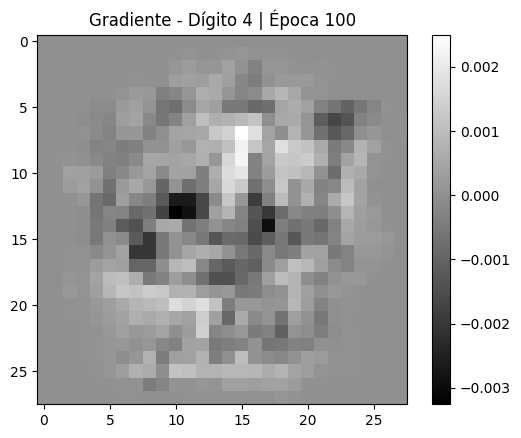

In [13]:
import numpy
losses = []
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)

    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    _, predicts = torch.max(outputs, 1)

    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()

    # Atividade 1: imprime época, perda e acurácia ao final de cada época
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
          .format(i+1, epochs, loss.data, accuracy))

    # Atividade 2: visualiza os gradientes dos pesos referentes à classe do dígito 4
    grad_digit4 = model.weight.grad[4, :].detach().numpy().reshape(28, 28)
    plt.imshow(grad_digit4, cmap='gray')
    plt.title(f'Gradiente - Dígito 4 | Época {i+1}')
    plt.colorbar()
    plt.show()


### Laço de treinamento dos pesos (com validação e armazenamento de métricas)

In [14]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for i in range(epochs):
    # Passada de treinamento
    inputs_train = Variable(x_train.view(-1, 28 * 28))
    outputs_train = model(inputs_train)
    loss_train = criterion(outputs_train, Variable(y_train))

    # Zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss_train.backward()
    optimizer.step()

    train_losses.append(loss_train.item())

    _, predicts_train = torch.max(outputs_train, 1)
    accuracy_train = (predicts_train.data.numpy() == y_train.numpy()).mean()
    train_accuracies.append(accuracy_train)

    # Passada de validação
    with torch.no_grad(): # Desabilita o cálculo de gradientes para validação
        inputs_val = Variable(x_val.view(-1, 28 * 28))
        outputs_val = model(inputs_val)
        loss_val = criterion(outputs_val, Variable(y_val))
        val_losses.append(loss_val.item())

        _, predicts_val = torch.max(outputs_val, 1)
        accuracy_val = (predicts_val.data.numpy() == y_val.numpy()).mean()
        val_accuracies.append(accuracy_val)

    print(f'Epoch [{i+1}/{epochs}], ' \
          f'Train Loss: {loss_train.item():.4f}, ' \
          f'Train Acc: {accuracy_train:.4f}, ' \
          f'Val Loss: {loss_val.item():.4f}, ' \
          f'Val Acc: {accuracy_val:.4f}')

Epoch [1/100], Train Loss: 0.2637, Train Acc: 0.9450, Val Loss: 0.3917, Val Acc: 0.8950
Epoch [2/100], Train Loss: 0.2623, Train Acc: 0.9450, Val Loss: 0.3907, Val Acc: 0.8950
Epoch [3/100], Train Loss: 0.2611, Train Acc: 0.9450, Val Loss: 0.3898, Val Acc: 0.8950
Epoch [4/100], Train Loss: 0.2598, Train Acc: 0.9450, Val Loss: 0.3889, Val Acc: 0.8950
Epoch [5/100], Train Loss: 0.2585, Train Acc: 0.9450, Val Loss: 0.3880, Val Acc: 0.8950
Epoch [6/100], Train Loss: 0.2573, Train Acc: 0.9450, Val Loss: 0.3871, Val Acc: 0.8950
Epoch [7/100], Train Loss: 0.2560, Train Acc: 0.9450, Val Loss: 0.3862, Val Acc: 0.8950
Epoch [8/100], Train Loss: 0.2548, Train Acc: 0.9460, Val Loss: 0.3854, Val Acc: 0.8950
Epoch [9/100], Train Loss: 0.2536, Train Acc: 0.9460, Val Loss: 0.3845, Val Acc: 0.8950
Epoch [10/100], Train Loss: 0.2524, Train Acc: 0.9460, Val Loss: 0.3837, Val Acc: 0.9050
Epoch [11/100], Train Loss: 0.2512, Train Acc: 0.9460, Val Loss: 0.3829, Val Acc: 0.9050
Epoch [12/100], Train Loss: 0.

In [15]:
print('Final loss:', loss.item())

Final loss: 0.2649877965450287


### Visualizando gráfico de perda durante o treinamento

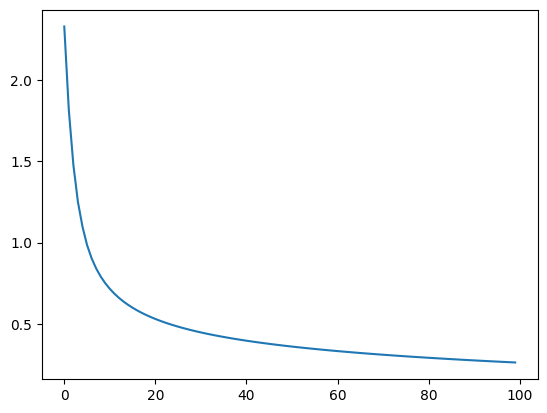

In [16]:
plt.plot(losses)

### Visualizando gráficos de perda e acurácia durante o treinamento

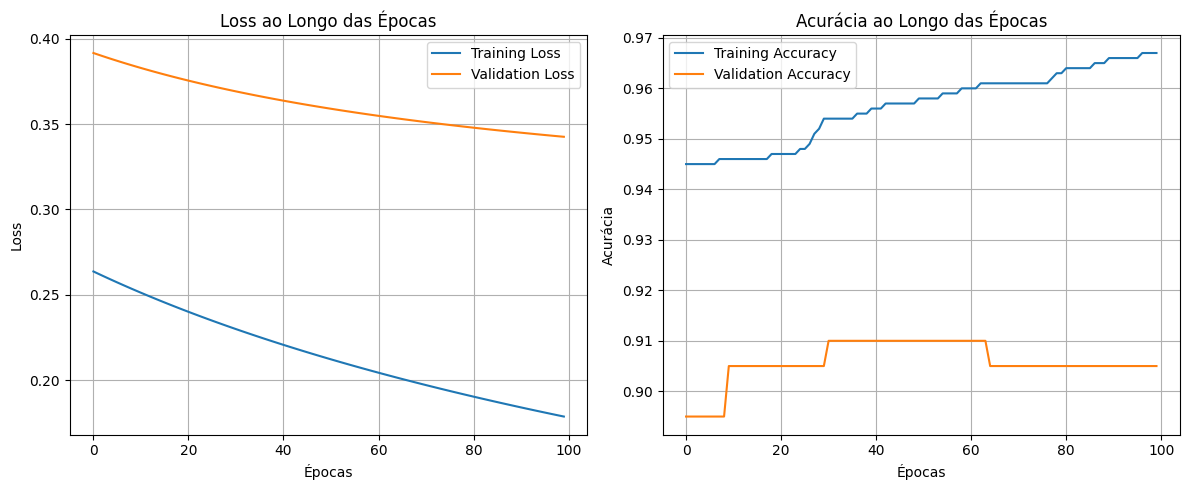

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Acurácia ao Longo das Épocas')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Avaliação

### Acurácia tanto no conjunto de treinamento como no conjunto de testes

In [18]:
def predict(model, input_data):
    outputs = model(Variable(input_data))
    _, predicts = torch.max(outputs, 1)

    return predicts.data

y_pred = predict(model, x_train.view(-1, 28*28))
accuracy = (y_pred.numpy() == y_train.numpy()).mean()
print('Accuracy:', accuracy)

Accuracy: 0.967


### Matriz de confusão com dados de treinamento e teste

In [19]:
print('Matriz de confusão:')
pd.crosstab(y_pred.numpy(), y_train.numpy())

Matriz de confusão:


col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,97,0,1,0,0,0,0,0,0,2
1,0,112,1,0,0,0,0,2,1,0
2,0,0,92,2,0,1,0,1,0,0
3,0,0,0,90,0,1,0,0,0,0
4,0,0,0,0,104,1,0,1,0,2
5,0,2,0,1,0,87,0,0,1,1
6,0,0,1,0,0,1,94,0,0,0
7,0,0,1,0,0,0,0,113,0,2
8,0,1,2,0,0,0,0,0,85,0


## Visualizando a matriz de pesos treinados

Observe que a matriz de peso treinado para cada classe mostra a importância dos pesos associados aos caracteres de cada classe.

weights: torch.Size([10, 784])
bias:    torch.Size([10])


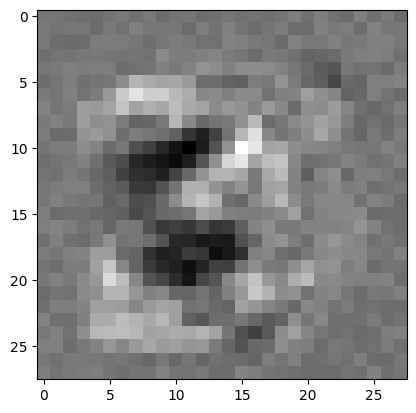

In [20]:
weights = model.state_dict()['weight']
print('weights:', weights.shape)

bias = model.state_dict()['bias']
print('bias:   ', bias.shape)

# Visualizando pesos da classe 3
plt.imshow(weights[3, :].numpy().reshape((28,28)),cmap = 'gray')
plt.show()

### Visualizando os pesos de todas as classes

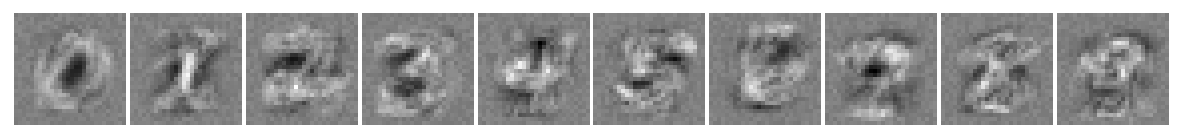

In [21]:
# cria um grid com as imagens
grid = torchvision.utils.make_grid(weights.view(-1, 1, 28, 28), normalize=True, pad_value=1.0, padding=1, nrow=10)

plt.figure(figsize=(15, 10))
plt.imshow(grid.numpy().transpose(1, 2, 0))
plt.axis('off');

### Diagrama da regressão softmax com visualização dos pesos W

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoSoftmaxArgmaxNMIST.png)

# Atividades

## Exercícios

- 1) Insira código no laço do treinamento para que no final de cada época,
     seja impresso: o número da época e a perda e a acurácia

- 2) Insira código no laço do treinamento para visualização dos valores dos gradientes referentes à classe do dígito 4, no final de cada época.

<details>
<summary>Mostrar Resultado</summary>

```python
losses = []
import numpy

import numpy
zs = []

for i in range(epochs):
    # Transforma a entrada para uma dimensão
    inputs = Variable(x_train.view(-1, 28 * 28))
    # Predict da rede
    outputs = model(inputs)
    
    # z0 a z9
    zs.append(outputs[1].detach().numpy())

    # calcula a perda
    loss = criterion(outputs, Variable(y_train))

    # zero, backpropagation, ajusta parâmetros pelo gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
    _, predicts = torch.max(outputs, 1)
    
    y_pred = predicts.data
    accuracy = (y_pred.numpy() == y_train.numpy()).mean()
    
    print('Epoch[{}/{}], loss: {:.6f}, acc: {:.6f}'
              .format(i+1, epochs, loss.data, accuracy))
    
    weights = model.state_dict()['weight']
    print('weights:', weights.shape)

    bias = model.state_dict()['bias']
    print('bias:   ', bias.shape)

    # Visualizando pesos da classe 3
    plt.imshow(weights[4, :].numpy().reshape((28,28)),cmap = 'gray')
    plt.show()
```

</details>

## Perguntas

1. Qual é o shape da matriz de entrada na rede?
    - (1000, 784) — as 1000 amostras de treinamento, cada uma com 28×28 = 784 pixels linearizados pelo .view(-1, 28*28).

2. Qual é o shape da saída da rede?
    - (1000, 10) — 1000 amostras, cada uma com 10 scores (um por classe/dígito), gerados pelo nn.Linear(784, 10).

3. Qual é o número total de parâmetros da rede, incluindo o bias?
    - 7.850 — a matriz de pesos tem shape (10, 784) = 7.840 parâmetros, mais o vetor de bias com shape (10,) = 10 parâmetros, totalizando 7.850.

# Aprendizados

- A mesma arquitetura usada na íris (uma camada linear) escala para o MNIST mudando apenas o número de entradas e saídas, o que mostra como a regressão softmax é uma generalização natural da regressão logística para múltiplas classes.
- Os pesos treinados de cada neurônio, quando reorganizados em 28×28, formam uma espécie de "imagem média" do dígito que aquele neurônio aprendeu a reconhecer, o que torna o modelo interpretável visualmente.
- Visualizar o gradiente do dígito 4 a cada época mostra como o modelo vai ajustando quais regiões da imagem são mais relevantes para aquela classe ao longo do treinamento.
- A CrossEntropyLoss já incorpora a função softmax internamente, então não é necessário aplicar softmax manualmente na saída da rede durante o treinamento.
